# 2 — Walkthrough: what is a forecast worth?

The whole pipeline on one day, then on sixty.

The question is deliberately not *how accurate are the models*. It is
**how much money does the accuracy buy**, and **which of the three
forecasts the money depends on** — which turns out not to be an even
split.

In [1]:
%matplotlib inline

import pandas as pd

from bess_dispatch.config import load_config
from bess_dispatch.data.loaders import load_site_frame, split_frame
from bess_dispatch.evaluation.benchmark import (
    ablation_table,
    fit_forecasters,
    run_benchmark,
    summarise_benchmark,
)
from bess_dispatch.forecasting.interface import (
    ForecastResult,
    actuals_for,
    forecast_horizon,
)
from bess_dispatch.optimization.builder import build_dispatch_model
from bess_dispatch.optimization.solve import solve_dispatch
from bess_dispatch.visualization import plots

config = load_config()
site = config.site()
frame = load_site_frame()
print(f'{site.battery.energy_capacity_mwh} MWh / {site.battery.p_charge_max_mw} MW, '
      f'round-trip {site.battery.round_trip_efficiency:.3f}')

1.0 MWh / 0.5 MW, round-trip 0.902


## Fit the forecasters

One model per series, each chosen by validation MAE rather than by
reputation. The choice is not uniform — gradient boosting wins on load
and **loses to a naive baseline on PV**. See `docs/forecasting.md`.

In [2]:
fitted = fit_forecasters(split_frame(frame, 'train'), horizon=24)
for target, model in fitted.items():
    print(f'{target:<16} {model.name}')

load_mw          gradient boosting
pv_mw            ridge
price_eur_mwh    ridge


## One day

Forecast the next 24 hours, solve against the forecast, and pull the
actuals for the same window so the plan can be scored on reality.

In [3]:
issue = pd.Timestamp('2020-01-16', tz='UTC')
forecast = forecast_horizon(fitted, frame, issue, 24)
truth = actuals_for(frame, forecast)

planned = solve_dispatch(build_dispatch_model(forecast, site, objective=config.objective))
print(planned.summary())
print(planned.cost_breakdown())

1,820.53 EUR over 24 periods - peak import 0.906 MW, throughput 0.80 MWh, optimal, 0.05s
{'energy': 1814.4018136432273, 'degradation': 1.602105263157895, 'demand_charge': 4.527956547070701}


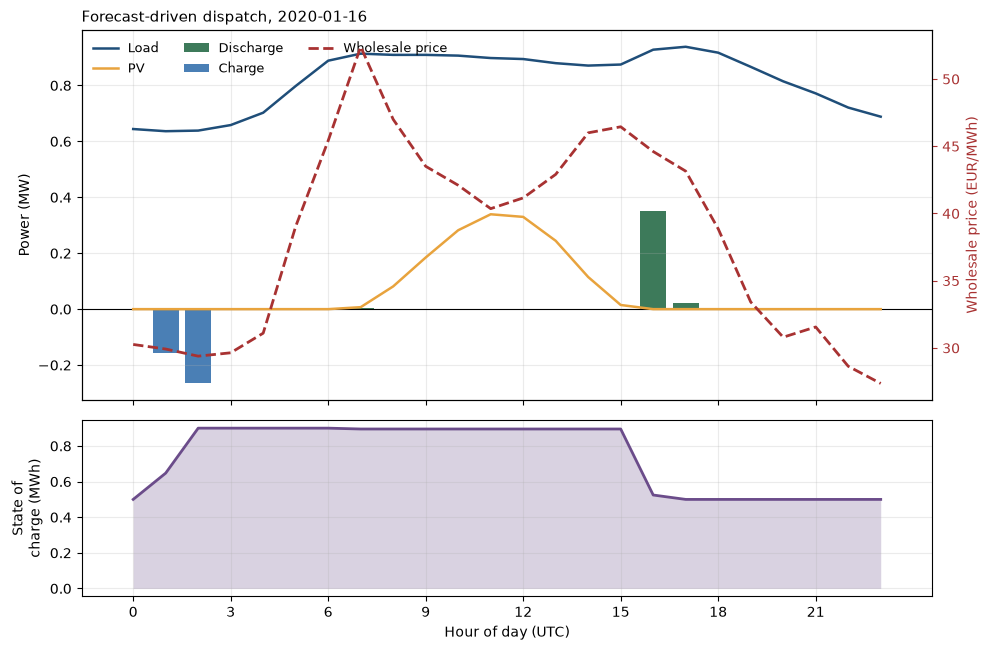

In [4]:
plots.plot_dispatch_day(
    planned, truth,
    timestamps=pd.DatetimeIndex(forecast.timestamps),
    title='Forecast-driven dispatch, 2020-01-16',
);

## Perfect foresight, through the identical code

`ForecastResult.from_actuals` wraps observed data in the same type a
model produces, so it goes through the same builder and the same
solver. That is what makes the comparison a measurement of
*information* rather than of two implementations.

In [5]:
perfect = solve_dispatch(
    build_dispatch_model(
        ForecastResult.from_actuals(truth), site, objective=config.objective
    )
)
print(f'forecast-driven {planned.total_cost_eur:>10,.2f} EUR')
print(f'perfect         {perfect.total_cost_eur:>10,.2f} EUR')
gap = planned.total_cost_eur - perfect.total_cost_eur
print(f'cost of not knowing {gap:>10,.2f} EUR')

forecast-driven   1,820.53 EUR
perfect           1,780.33 EUR
cost of not knowing      40.21 EUR


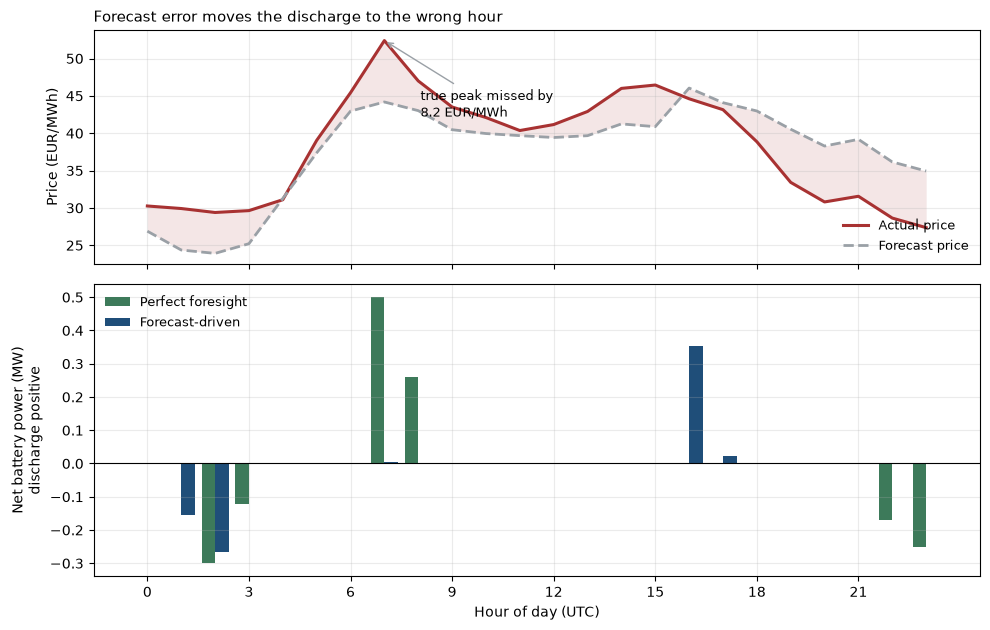

In [6]:
plots.plot_forecast_vs_perfect(
    planned, perfect, truth, forecast,
    timestamps=pd.DatetimeIndex(forecast.timestamps),
);

The forecast under-called the true morning peak and over-called the
afternoon, so the two controllers discharge nine hours apart. **Both
schedules are optimal for the prices they were given** — a discharge in
the wrong hour is not the optimizer failing.

## Sixty days, seven arms

Every arm solved over the same days and priced against the same
actuals by the same function. Only what the controller knew varies.

The three `+ actual` arms are the ablation: each hands the optimizer
one series' true values and leaves the other two forecast.

In [7]:
results = run_benchmark(site, objective=config.objective, frame=frame, fitted=fitted)
summary = summarise_benchmark(results)
summary[['total_cost_eur', 'saving_eur', 'saving_pct_wholesale', 'value_captured_pct']].round(3)

,total_cost_eur,saving_eur,saving_pct_wholesale,value_captured_pct
arm,,,,
no battery,95047.526,0.000,0.000,0.000
rule-based,95039.740,7.786,0.025,1.368
forecast,94815.225,232.302,0.734,40.801
forecast + actual price,94482.442,565.085,1.786,99.249
forecast + actual load,94812.395,235.131,0.743,41.297
forecast + actual PV,94809.584,237.942,0.752,41.791
perfect foresight,94478.167,569.360,1.800,100.000


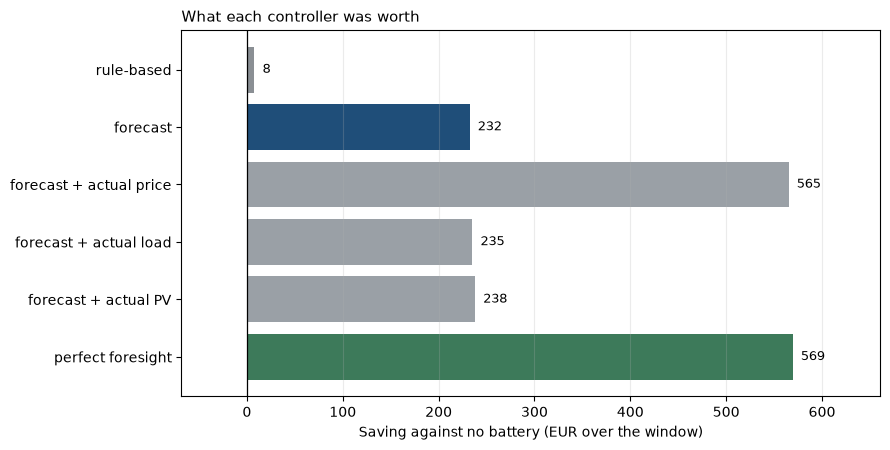

In [8]:
plots.plot_arm_comparison(summary);

Two things worth pausing on.

**The rule-based controller is nearly worthless here.** Greedy
self-consumption can only charge from surplus PV, and in a German
January there essentially never is any. That is the controller that
ships in the inverter, and it is the comparison a buyer actually cares
about — not the no-battery case.

**Savings are quoted against two denominators.** The battery can only
move the wholesale energy component; network charges and levies ride
along with every MWh whenever it is taken.

## Which forecast does the money depend on?

In [9]:
ablation = ablation_table(summary)
print(f'total gap to perfect foresight: {ablation.attrs["total_gap_eur"]:,.2f} EUR')
ablation.round(2)

total gap to perfect foresight: 337.06 EUR


,cost_eur,gap_closed_eur,gap_closed_pct
series made perfect,,,
price,94482.44,332.78,98.73
load,94812.40,2.83,0.84
pv,94809.58,5.64,1.67


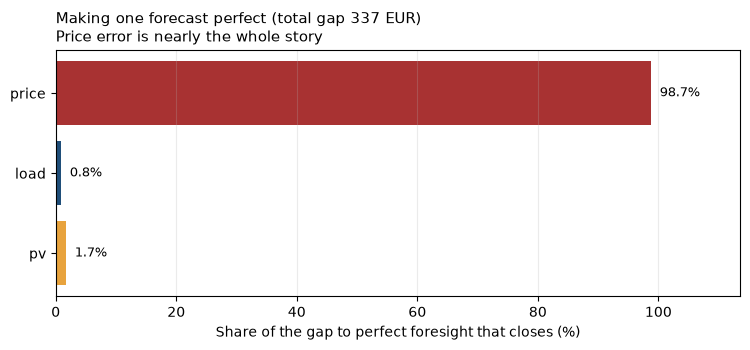

In [10]:
plots.plot_ablation(ablation);

**Price error is nearly the whole story.** Making the price forecast
perfect closes 98.7% of the gap; load and PV together account for
2.5%.

This is the result that changes what you would do next. Effort spent
improving load or PV accuracy would buy almost nothing on this site;
probabilistic *price* forecasting feeding a risk-aware dispatch is
where the remaining value is.

It also puts the load-data caveat in proportion. Load here is a
national aggregate rescaled to one site, and therefore smoother and
easier to forecast than a real building — but since load accuracy is
worth 0.8% of the gap, even a far worse load forecaster would barely
move the answer.

## Where this goes next

- `python -m bess_dispatch.run --stage rolling` — the hourly
  receding-horizon controller, which recovers most of what perfect
  information is worth in the day-ahead framing.
- `python -m bess_dispatch.run --stage scenarios` — sizing,
  efficiency, degradation and volatility sweeps, including the regime
  where the forecast-driven controller **loses money**.
- `streamlit run app/streamlit_app.py` — the same functions behind
  sliders.